<a href="https://colab.research.google.com/github/AkshatkMalik/python-data-science-toolkit/blob/main/Decesion_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ASSIGNMENT: DECISION TREE CLASSIFICATION**

**Task 1: Data Preparation**

In this task, we import the heart disease dataset that is provided via the URL and stored as Excel sheets (Description and Heart_disease). We explore the data structure and content to identify the sheet structure and the data type of all variables.

In [5]:

import numpy as np
import pandas as pd

# 1. Load the Excel file and check available sheets
excel_file = pd.ExcelFile('heart_disease.xlsx')
print('Sheet names:', excel_file.sheet_names)

# Load the main data sheet ('Heart_disease')
df = pd.read_excel('heart_disease.xlsx', sheet_name='Heart_disease')

print('--- Dataset Overview ---')
print(f'Dataset Shape (Rows, Columns): {df.shape}')
print('\nFirst 3 Rows:')
display(df.head(3))

Sheet names: ['Description', 'Heart_disease']
--- Dataset Overview ---
Dataset Shape (Rows, Columns): (908, 13)

First 3 Rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0


**Task 2: Exploratory Data Analysis (EDA)**

In this task, we analyze the data structure and volume, check for missing values, and process categorical versus numerical attributes. In addition, we plot the feature distributions as well as the correlation matrix.

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   908 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
 13  target    908 non-null    int64  
dtypes: bool(1), float64(1), int64(6), object(6)
memory usage: 93.2+ KB
None

Missing Values per Column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak 

,age,trestbps,chol,thalch,oldpeak,num,target
count,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.864537,1.008811,0.560573
std,9.158031,20.401608,112.097949,26.804929,1.060433,1.144436,0.496591
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000,1.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000,1.000000


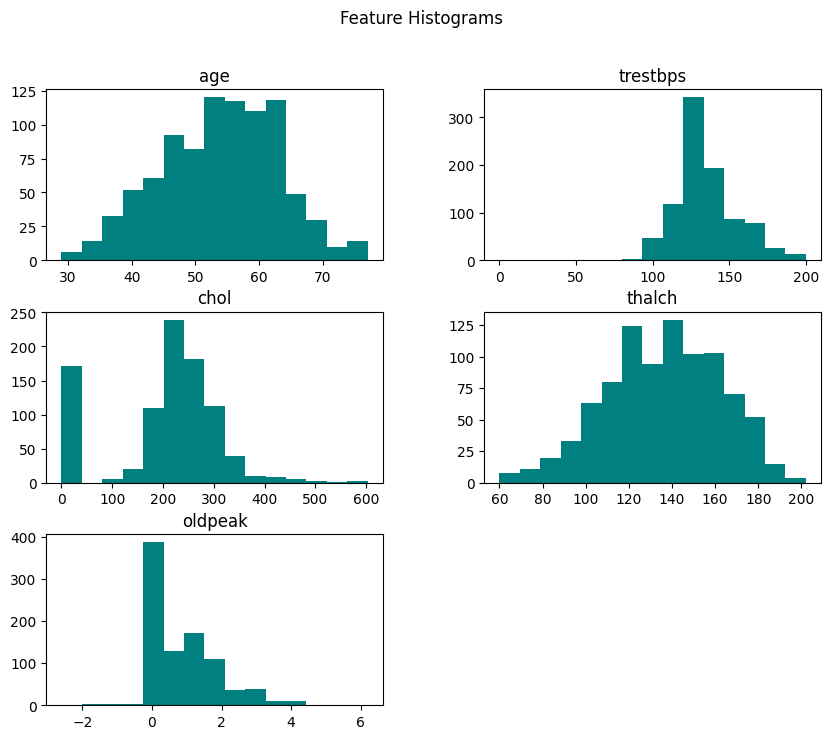

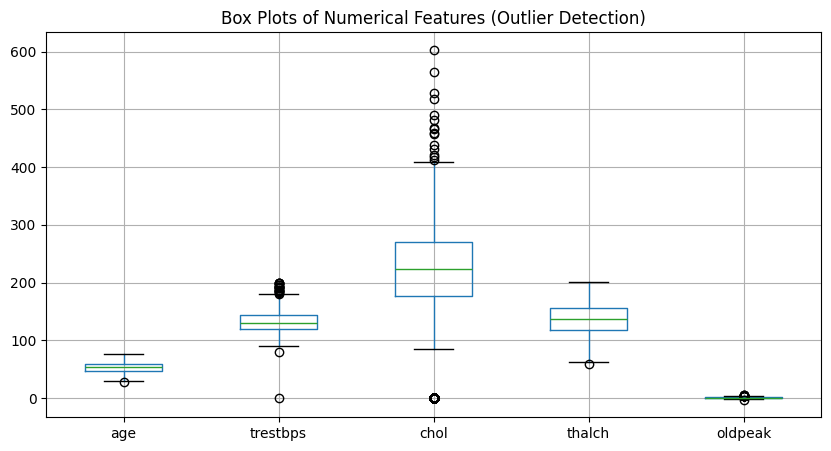

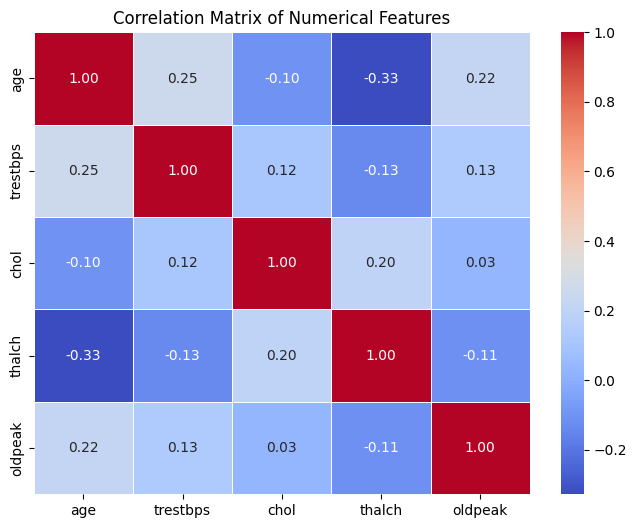

In [11]:

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Check data types and missing values
print('Data Types and Missing Values:')
print(df.info())
print('\nMissing Values per Column:\n', df.isnull().sum())

# 2. Summary statistics of numerical columns
print('\nSummary Statistics:')
display(df.describe())

# 3. Visualize Feature Distributions (Histograms)
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
df[num_cols].hist(bins=15, figsize=(10, 8), color='teal', grid=False)
plt.suptitle('Feature Histograms')
plt.show()

# 4. Visualize Outliers (Box Plots)
plt.figure(figsize=(10, 5))
df[num_cols].boxplot()
plt.title('Box Plots of Numerical Features (Outlier Detection)')
plt.show()

# 5. Correlation Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5
)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Task 3: Feature Engineering & Preprocessing**

In this stage of the task, first, we need to deal with missing values (imputing missing oldpeak values with the median). Secondly, to make the input data suitable for the decision tree, we need to scale numerical features if necessary and encode categorical variables using One-Hot/Label encoding.

In [7]:


# 1. Handle missing values: Impute missing 'oldpeak' values with the median
df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)
print('Missing values after imputation:', df.isnull().sum().sum())

# 2. Separate Features (X) and Target (y)
# Binarize 'num' into binary classification (0 = No Disease, 1 = Disease present)
df['target'] = (df['num'] > 0).astype(int)

X = df.drop(columns=['num', 'target'])
y = df['target']

# 3. Handle Categorical Variables using pd.get_dummies (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)
print('Encoded Features Shape:', X_encoded.shape)
display(X_encoded.head(3))

Missing values after imputation: 0
Encoded Features Shape: (908, 19)


/tmp/ipykernel_1860/1293028468.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)


,age,trestbps,chol,fbs,thalch,oldpeak,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,exang_True,exang_FALSE,exang_TURE,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145,233,True,150,2.3,1,0,0,1,0,0,0,0,0,0,0,0,0
1,41,135,203,False,132,0.0,1,1,0,0,1,0,0,0,0,1,0,0,0
2,57,140,192,False,148,0.4,1,0,0,0,1,0,0,0,0,1,0,0,0


**Task 4: Decision Tree Classification**

In this task, we split our dataset in 80/20 ratio and train a Decision Tree Classifier, using scikit-learn. We also calculate Accuracy, Precision, Recall, F1-Score and ROC-AUC to analyze the quality of our model.

In [8]:

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)
print(f'Training Set Rows: {X_train.shape[0]}')
print(f'Testing Set Rows: {X_test.shape[0]}')

# 2. Initialize and Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 3. Predict on Testing Set
y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:, 1]

# 4. Evaluate Performance Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print('--- Model Evaluation Metrics ---')
print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-Score:  {f1:.4f}')
print(f'ROC-AUC:   {roc_auc:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Training Set Rows: 726
Testing Set Rows: 182
--- Model Evaluation Metrics ---
Accuracy:  0.7198
Precision: 0.7283
Recall:    0.7204
F1-Score:  0.7243
ROC-AUC:   0.7198

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.72      0.72        89
           1       0.73      0.72      0.72        93

    accuracy                           0.72       182
   macro avg       0.72      0.72      0.72       182
weighted avg       0.72      0.72      0.72       182



**Task 5: Hyperparameter Tuning**

In this task, using the Grid Search method (GridSearchCV), we will tune the main hyperparameters of the Decision Tree model, such as max_depth, min_samples_split, and criterion, to find optimal values that minimize overfitting.

In [9]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
}

# Setup Grid Search
grid_search = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(
    estimator=grid_search,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

grid.fit(X_train, y_train)

print('Best Hyperparameters Found:')
print(grid.best_params_)
print(f'Best Cross-Validation Accuracy: {grid.best_score_:.4f}')

# Train best model
best_dt = grid.best_estimator_
y_pred_best = best_dt.predict(X_test)
print(f'Tuned Test Accuracy: {accuracy_score(y_test, y_pred_best):.4f}')

Best Hyperparameters Found:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.7700
Tuned Test Accuracy: 0.7637


**Task 6: Model Evaluation, Visualization, and Analysis**

The second task is to visualize the obtained tree and analyze its structure to identify the most important factors that impact the target variable in the given dataset.

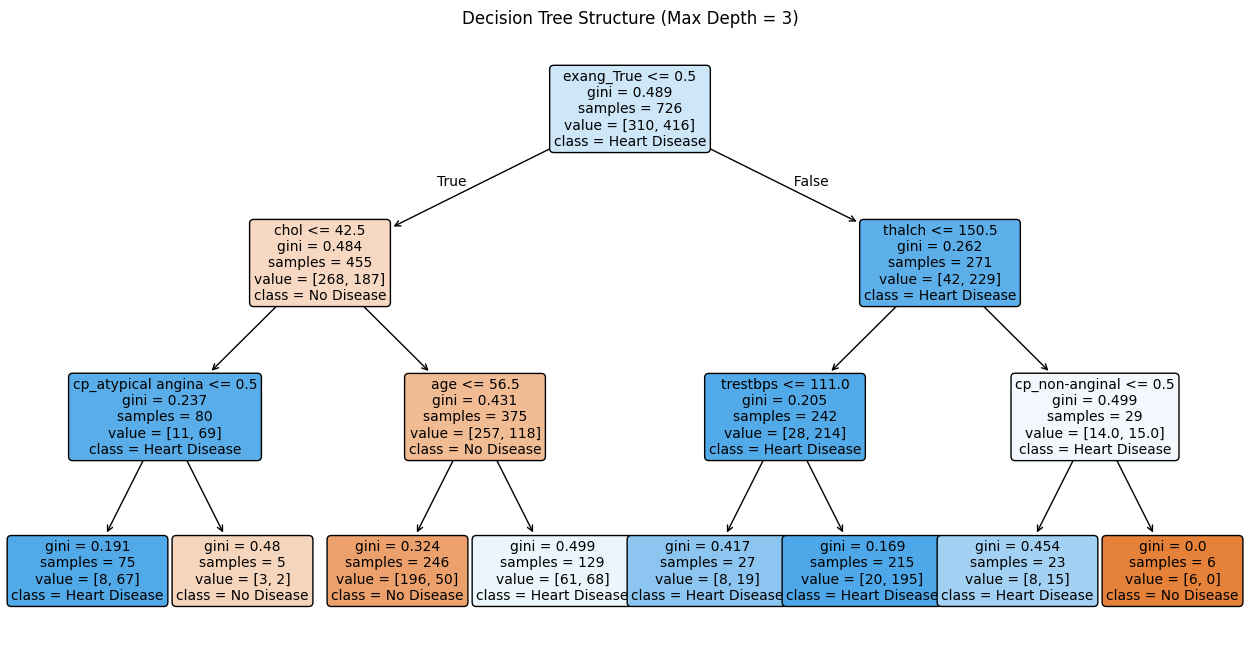

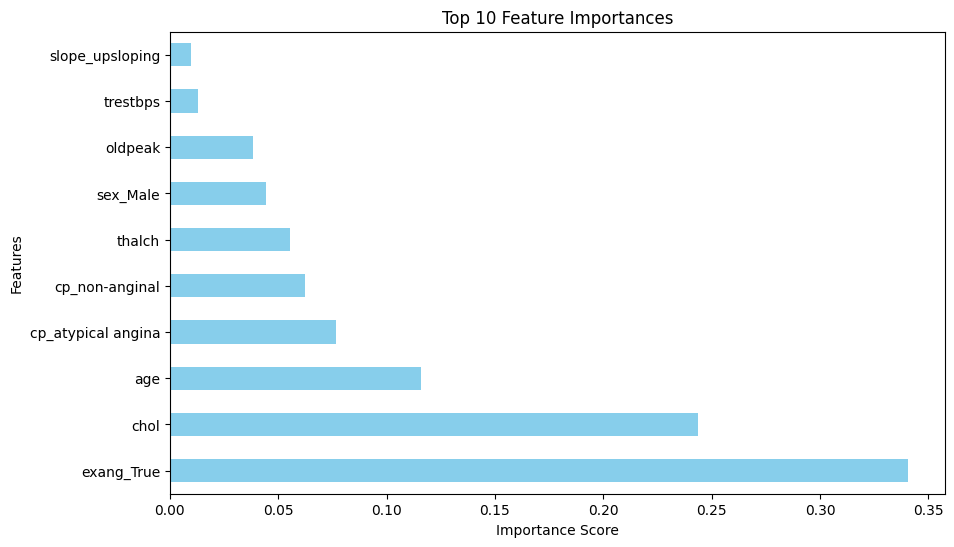

In [10]:

from sklearn.tree import plot_tree

# 1. Visualize the Decision Tree (using a shallow max_depth=3 for clear readability)
plt.figure(figsize=(16, 8))
plot_tree(
    best_dt
    if hasattr(best_dt, 'max_depth') and best_dt.max_depth == 3
    else DecisionTreeClassifier(max_depth=3, random_state=42).fit(
        X_train, y_train
    ),
    feature_names=X_encoded.columns,
    class_names=['No Disease', 'Heart Disease'],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title('Decision Tree Structure (Max Depth = 3)')
plt.show()

# 2. Feature Importance Plot
feature_importances = pd.Series(best_dt.feature_importances_, index=X_encoded.columns)
plt.figure(figsize=(10, 6))
feature_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

**Task 7: Interview Questions & Core Concepts**

1. What are some common hyperparameters of decision tree models and how do they affect the model's performance?


    The hyperparameters in a decision tree are:
    1. max_depth: It determines the maximum depth of the tree. Hence, it controls over/underfitting of  the model
    2. min_samples_split: This parameter determines the minimum number of samples required to split an internal node. Increasing this number reduces the risk of overfitting
    3. criterion: It determines the function to measure the quality of a split. In this case, choosing `gini` is computationally faster but results in slightly worse performance as compared to `entropy`
---

2. What is the difference between Label encoding and One-hot encoding?


    Label Encoding is a type of encoding where we convert the strings into a column of integers (eg `0,1,2`) whereas One-hot encoding creates a binary column for each unique category. Label encoding introduces bias into the data as you may be introducing a false ordering into your data (eg `0,1,2`). One-hot encoding is better than label encoding in such cases but can lead to sparsity issues in case of high cardinality data. Also, label encoding doesn't change the shape of the original dataframe while one-hot encoding requires additional columns to represent the encoded data.